# Yes/No Question Rate in Paraphrased Questions

Two complementary signals from `results/sharechat/atomic_fact_confidence.csv`:

1. **Question heuristic** — does `paraphrased_question` start with a polar-question word?
2. **Answer signal** — does the majority of `sample_1..5` start with *Yes* or *No*?

In [1]:
import re
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

pd.set_option('display.max_colwidth', 120)
plt.rcParams['figure.dpi'] = 120

INPUT_CSV = '../results/sharechat/atomic_fact_confidence.csv'
SAMPLE_COLS = ['sample_1', 'sample_2', 'sample_3', 'sample_4', 'sample_5']

In [2]:
df = pd.read_csv(INPUT_CSV)
print(f"Rows: {len(df):,}  |  Unique paraphrased questions: {df['paraphrased_question'].nunique():,}")
df.head(2)

Rows: 5,313  |  Unique paraphrased questions: 5,249


,model,problem,has_search,search_calls,atomic_fact,attributed_to_search,reasoning,sampler_response,paraphrased_question,sample_1,sample_2,sample_3,sample_4,sample_5,num_clusters,cluster_sizes,entropy
0,gemini-3-pro-preview,Which President was the most pro-religious freedom?,False,0,Thomas Jefferson is widely considered the most pro-religious freedom president.,False,No search results available for this query.,Thomas Jefferson is widely considered the most pro-religious freedom president due to his foundational role in estab...,Which U.S. president is most widely regarded as the most supportive of religious freedom?,Thomas Jefferson,Thomas Jefferson,Thomas Jefferson,Thomas Jefferson,Thomas Jefferson,1.0,[5],0.0
1,gemini-3-pro-preview,Which President was the most pro-religious freedom?,False,0,Thomas Jefferson played a foundational role in establishing the concept of religious freedom in American law.,False,No search results available for this query.,Thomas Jefferson is widely considered the most pro-religious freedom president due to his foundational role in estab...,Who played a foundational role in establishing the concept of religious freedom in American law?,Thomas Jefferson and James Madison.,Thomas Jefferson and James Madison,Thomas Jefferson and James Madison.,Thomas Jefferson and James Madison,Thomas Jefferson and James Madison.,1.0,[5],0.0


## 1. Question heuristic

A question is polar/yes-no if it starts with an auxiliary or copula verb.

In [3]:
YN_STARTERS = (
    'did ', 'do ', 'does ', 'is ', 'are ', 'was ', 'were ',
    'has ', 'have ', 'can ', 'could ', 'would ', 'will ', 'should ',
    'is it', 'does it',
)

def question_is_yn(q) -> bool:
    if not isinstance(q, str):
        return False
    return q.strip().lower().startswith(YN_STARTERS)

df['q_is_yn'] = df['paraphrased_question'].apply(question_is_yn)

q_rate = df['q_is_yn'].mean()
print(f"Question-heuristic yes/no rate: {q_rate:.1%}  "
      f"({df['q_is_yn'].sum():,} / {len(df):,} rows)")

# Unique-question level
df_pq = df.drop_duplicates('paraphrased_question')[['paraphrased_question', 'q_is_yn']]
uq_rate = df_pq['q_is_yn'].mean()
print(f"Unique-question level            : {uq_rate:.1%}  "
      f"({df_pq['q_is_yn'].sum():,} / {len(df_pq):,} unique questions)")

Question-heuristic yes/no rate: 67.3%  (3,573 / 5,313 rows)
Unique-question level            : 67.7%  (3,553 / 5,250 unique questions)


## 2. Answer signal

A row has a yes/no *answer* if the majority of samples start with **Yes** or **No**
(case-insensitive, allowing punctuation immediately after).

In [4]:
_YN_PAT = re.compile(r'^\s*(yes|no)[.,!?;\s]', re.IGNORECASE)

def sample_yn_count(row) -> int:
    """Number of samples that start with yes/no."""
    return sum(
        1 for col in SAMPLE_COLS
        if isinstance(row.get(col), str) and _YN_PAT.match(row[col])
    )

df['ans_yn_count'] = df[SAMPLE_COLS].apply(
    lambda row: sum(1 for v in row if isinstance(v, str) and _YN_PAT.match(v)),
    axis=1
)
df['ans_is_yn'] = df['ans_yn_count'] >= 3   # majority of 5 samples

a_rate = df['ans_is_yn'].mean()
print(f"Answer-signal yes/no rate (majority≥3): {a_rate:.1%}  "
      f"({df['ans_is_yn'].sum():,} / {len(df):,} rows)")

print("\nDistribution of how many samples start with yes/no:")
print(df['ans_yn_count'].value_counts().sort_index().rename('rows').to_string())

Answer-signal yes/no rate (majority≥3): 62.0%  (3,296 / 5,313 rows)

Distribution of how many samples start with yes/no:
ans_yn_count
0    1700
1      99
2     218
3     465
4     803
5    2028


## 3. Agreement between question heuristic and answer signal

In [5]:
agree = (df['q_is_yn'] == df['ans_is_yn']).mean()
print(f"Question / answer agreement: {agree:.1%}")

df['label'] = df.apply(
    lambda r: 'Q=Y A=Y' if r['q_is_yn'] and r['ans_is_yn']
              else 'Q=Y A=N' if r['q_is_yn'] and not r['ans_is_yn']
              else 'Q=N A=Y' if not r['q_is_yn'] and r['ans_is_yn']
              else 'Q=N A=N',
    axis=1
)
print("\nCross-tab (Q = question heuristic, A = answer signal):")
print(df['label'].value_counts().to_string())

# Conservative estimate: both signals agree it's yes/no
both_yn = (df['q_is_yn'] & df['ans_is_yn']).mean()
# Liberal estimate: either signal says yes/no
either_yn = (df['q_is_yn'] | df['ans_is_yn']).mean()
print(f"\nConservative (both agree): {both_yn:.1%}")
print(f"Liberal (either agrees)  : {either_yn:.1%}")

Question / answer agreement: 92.1%

Cross-tab (Q = question heuristic, A = answer signal):
label
Q=Y A=Y    3224
Q=N A=N    1668
Q=Y A=N     349
Q=N A=Y      72

Conservative (both agree): 60.7%
Liberal (either agrees)  : 68.6%


## 4. Plots

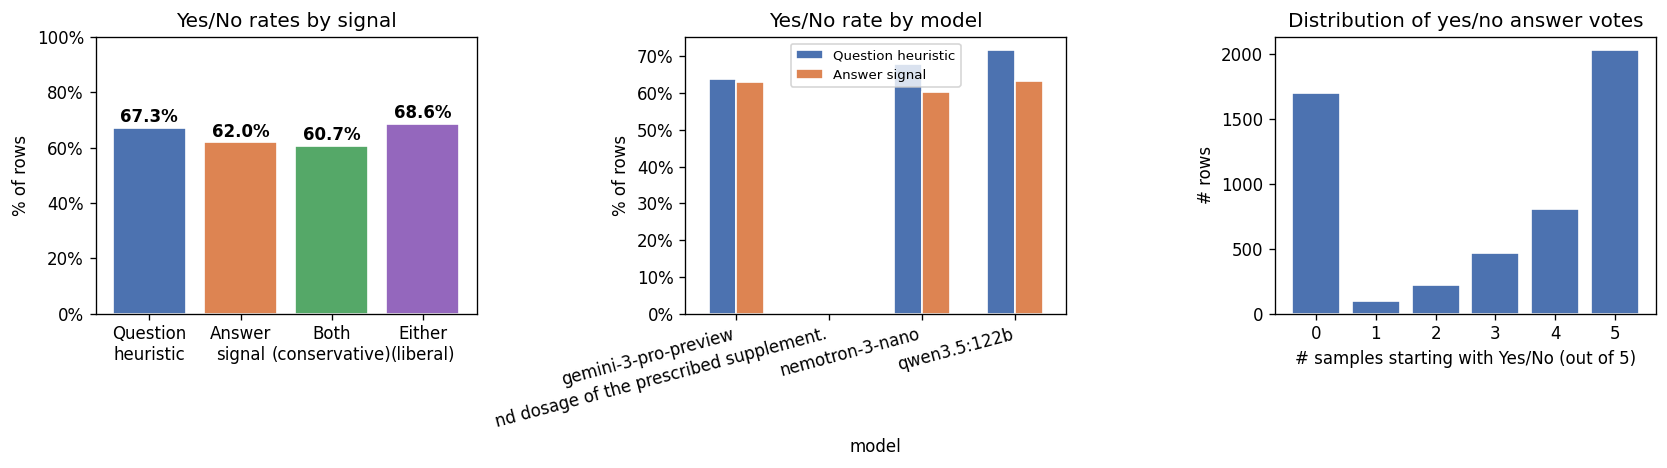

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# -- Bar: rates side by side --
rates = {
    'Question\nheuristic': q_rate,
    'Answer\nsignal': a_rate,
    'Both\n(conservative)': both_yn,
    'Either\n(liberal)': either_yn,
}
bars = axes[0].bar(rates.keys(), [v * 100 for v in rates.values()],
                   color=['#4C72B0', '#DD8452', '#55A868', '#9467BD'],
                   edgecolor='white')
for bar, val in zip(bars, rates.values()):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                 f'{val:.1%}', ha='center', va='bottom', fontsize=10, fontweight='bold')
axes[0].set_ylim(0, 100)
axes[0].yaxis.set_major_formatter(mticker.PercentFormatter())
axes[0].set_title('Yes/No rates by signal')
axes[0].set_ylabel('% of rows')

# -- Stacked bar by model --
by_model = df.groupby('model')[['q_is_yn', 'ans_is_yn']].mean() * 100
by_model.plot(kind='bar', ax=axes[1], color=['#4C72B0', '#DD8452'],
              edgecolor='white', width=0.6)
axes[1].set_title('Yes/No rate by model')
axes[1].set_ylabel('% of rows')
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter())
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=15, ha='right')
axes[1].legend(['Question heuristic', 'Answer signal'], fontsize=8)

# -- Histogram: ans_yn_count distribution --
counts = df['ans_yn_count'].value_counts().sort_index()
axes[2].bar(counts.index, counts.values, color='#4C72B0', edgecolor='white')
axes[2].set_xticks(range(6))
axes[2].set_xlabel('# samples starting with Yes/No (out of 5)')
axes[2].set_ylabel('# rows')
axes[2].set_title('Distribution of yes/no answer votes')

plt.tight_layout()
plt.show()

## 5. Interesting cases

In [7]:
# Q says yes/no but answers are not yes/no
print("=== Q=YES but answers are NOT yes/no (false positives in question heuristic) ===")
fp = df[df['q_is_yn'] & ~df['ans_is_yn']][['paraphrased_question', 'sample_1']]
for _, row in fp.head(8).iterrows():
    print(f"  Q: {row['paraphrased_question'][:90]}")
    print(f"  A: {str(row['sample_1'])[:90]}")
    print()

print("=== Q=NO but answers ARE yes/no (question heuristic misses these) ===")
fn = df[~df['q_is_yn'] & df['ans_is_yn']][['paraphrased_question', 'sample_1']]
for _, row in fn.head(8).iterrows():
    print(f"  Q: {row['paraphrased_question'][:90]}")
    print(f"  A: {str(row['sample_1'])[:90]}")
    print()

=== Q=YES but answers are NOT yes/no (false positives in question heuristic) ===
  Q: Is it true that: When `v` is 0, the `if` condition in `__getitem__` is false.?
  A: Yes.

  Q: Is it true that: The iteration terminates successfully once a match is found.?
  A: True.

  Q: Is the quantum boundary in this model non-orientable?
  A: Please specify the model, as context is missing.

  Q: Is the described system a closed-loop system?
  A: Please provide the description of the system.

  Q: Is it true that: The link between coding proficiency and LLM proficiency is largely causal
  A: False.

  Q: Can the synth sound be recreated using a basic subtractive synthesizer?
  A: It depends on the specific sound.

  Q: Is it true that: The sound requires a mix of a sine wave.?
  A: False.

  Q: Is it true that: The filter has a relatively low cutoff frequency.?
  A: Insufficient context to determine.

=== Q=NO but answers ARE yes/no (question heuristic misses these) ===
  Q: According to neuroa